<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/better-visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Better Visualisations
...todo...


...TODO: need to think about copying in the most basic examples of LR experiments to show the benefit for the Loss curves.

In [13]:
# Install Training Instrumentation Toolkit
# (locked to specific git revision so this notebook always works)
import os
import sys
if not os.path.isdir('training-instrumentation-toolkit'):
  !git clone https://github.com/malcolmlett/training-instrumentation-toolkit.git
  !cd training-instrumentation-toolkit && git checkout 7b860a4
sys.path.append('training-instrumentation-toolkit')

# Imports
import sys
import train_instrumentation as tinstr
import train_explainer as texpl
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import matplotlib.ticker as mticker
import sklearn
import scipy

# Prefer consistent behaviour
tf.config.experimental.enable_op_determinism()

Cloning into 'training-instrumentation-toolkit'...
remote: Enumerating objects: 1430, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 1430 (delta 107), reused 73 (delta 33), pack-reused 1239 (from 1)
Receiving objects: 100% (1430/1430), 120.49 MiB | 21.74 MiB/s, done.
Resolving deltas: 100% (856/856), done.
Note: switching to '7b860a4'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 7b860a4 Merge remote-tracking branch 'refs/remotes/origin/

In [2]:
# Versions and hardware used when this notebook was last succesfully run
print(f"Python:     {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {tf.keras.__version__}")
print(f"Numpy:      {np.__version__}")
print(f"Devices:    {tf.config.list_physical_devices()}")

Python:     3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
TensorFlow: 2.18.0
Keras:      3.8.0
Numpy:      2.0.2
Devices:    [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# Setup

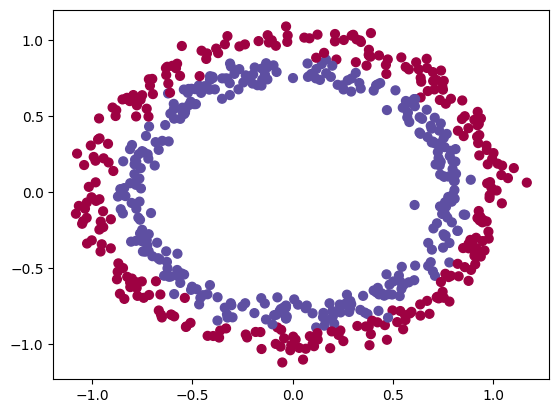

In [6]:
# Using a slightly more elaborate model than needed for such a simple task in order
# to illustrate how dropout and normalization layers appear in visualisations
def binary_classification_model():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(5, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(1, activation='sigmoid', kernel_initializer='he_normal')
  ])
  return model

def binary_classification_dataset():
  np.random.seed(1)
  train_X, train_Y = sklearn.datasets.make_circles(n_samples=3000, noise=.05)
  train_X = train_X
  train_Y = train_Y.reshape((-1, 1))
  return train_X, train_Y

train_X, train_Y = binary_classification_dataset()
plt.scatter(train_X[0:600, 0], train_X[0:600, 1], c=train_Y[0:600], s=40, cmap=plt.cm.Spectral);
plt.show()

# Custom Training Loop
This illustrates the simplest form of a custom training loop that collects the following while also providing some of the basic support that you get out of the box from the standard model.fit():
* Loss and metrics per-step instead of per-epoch
* Variables at each step (ie: weights, biases, etc.)
* Gradients at each step (of weights, biases, etc.)
* Layer outputs
* Gradients of layer outputs

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_121']
Received: inputs=Tensor(shape=(32, 2))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_121']
Received: inputs=Tensor(shape=(12, 2))
  warnings.warn(msg)


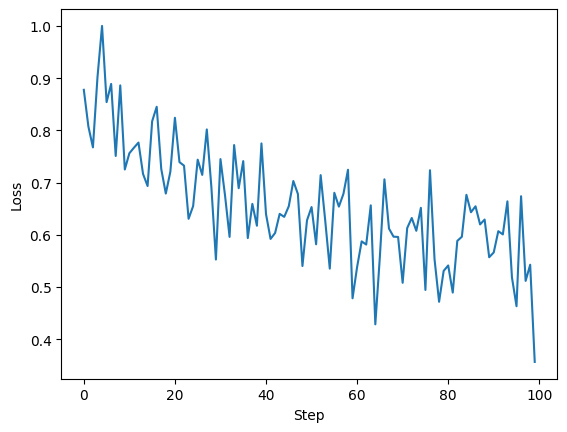

In [20]:
def custom_fit(model, train_dataset, epochs, optimizer):
  # unpack model during training so we get access to individual layer outputs
  monitoring_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[model.outputs] + [layer.output for layer in model.layers])

  loss_history = []
  metrics_history = []
  variables_history = []
  gradients_history = []
  layer_outputs_history = []
  layer_gradients_history = []

  for epoch in range(epochs):
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
      with tf.GradientTape() as tape:
        monitoring_outputs = monitoring_model(x_batch_train, training=True)
        y_pred = monitoring_outputs[0][0]
        layer_outputs = monitoring_outputs[1:]
        loss = model.compute_loss(x_batch_train, y_batch_train, y_pred, training=True)
        loss = optimizer.scale_loss(loss)
      all_grads = tape.gradient(loss, model.trainable_weights + layer_outputs)
      trainable_grads = all_grads[:len(model.trainable_variables)]
      output_grads = all_grads[len(model.trainable_variables):]
      optimizer.apply_gradients(zip(trainable_grads, model.trainable_weights))
      metrics = model.compute_metrics(x_batch_train, y_batch_train, y_pred)

      loss_history.append(loss)
      metrics_history.append(metrics)
      variables_history.append([tf.identity(v) for v in model.trainable_variables])
      gradients_history.append(trainable_grads)
      layer_outputs_history.append(layer_outputs)
      layer_gradients_history.append(output_grads)

  return loss_history, metrics_history, variables_history, gradients_history, layer_outputs_history, layer_gradients_history

# try it out
model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])
train_dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)).batch(32)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
hists = custom_fit(model, train_dataset, 5, optimizer)

# plot loss curve
plt.plot(hists[0])
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()


## Using Toolkit for capturing data

In [52]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])
train_X, train_Y = binary_classification_dataset()
dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)).batch(32)
history = tinstr.fit(model, dataset, epochs=100, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

Epoch    50 - 1.87s/epoch: accuracy: 0.9580  loss: 0.1100  mse: 0.0304  
Epoch   100 - 1.57s/epoch: accuracy: 0.9657  loss: 0.0826  mse: 0.0240  
Epoch   150 - 1.60s/epoch: accuracy: 0.9733  loss: 0.0722  mse: 0.0200  
Epoch   200 - 1.58s/epoch: accuracy: 0.9730  loss: 0.0697  mse: 0.0195  
Epoch   250 - 1.61s/epoch: accuracy: 0.9747  loss: 0.0724  mse: 0.0203  
Epoch   300 - 1.60s/epoch: accuracy: 0.9800  loss: 0.0605  mse: 0.0167  
Epoch   350 - 1.54s/epoch: accuracy: 0.9753  loss: 0.0647  mse: 0.0183  
Epoch   400 - 1.58s/epoch: accuracy: 0.9767  loss: 0.0608  mse: 0.0176  
Epoch   450 - 1.54s/epoch: accuracy: 0.9773  loss: 0.0650  mse: 0.0181  
Epoch   500 - 1.57s/epoch: accuracy: 0.9810  loss: 0.0538  mse: 0.0150  
Total training time: 803.3 sec


## Overview Plots

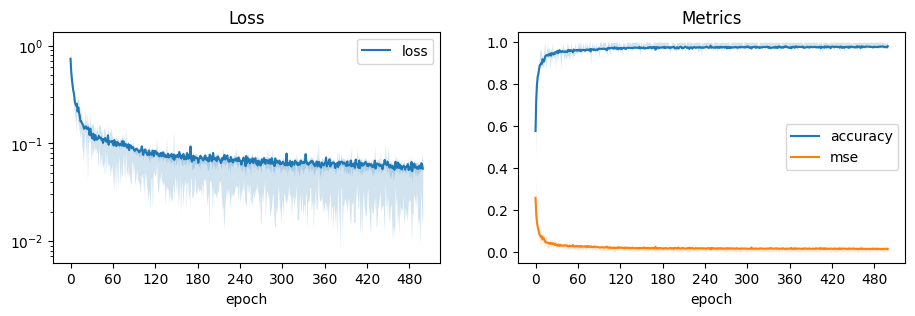

In [53]:
tinstr.plot_train_history(history)

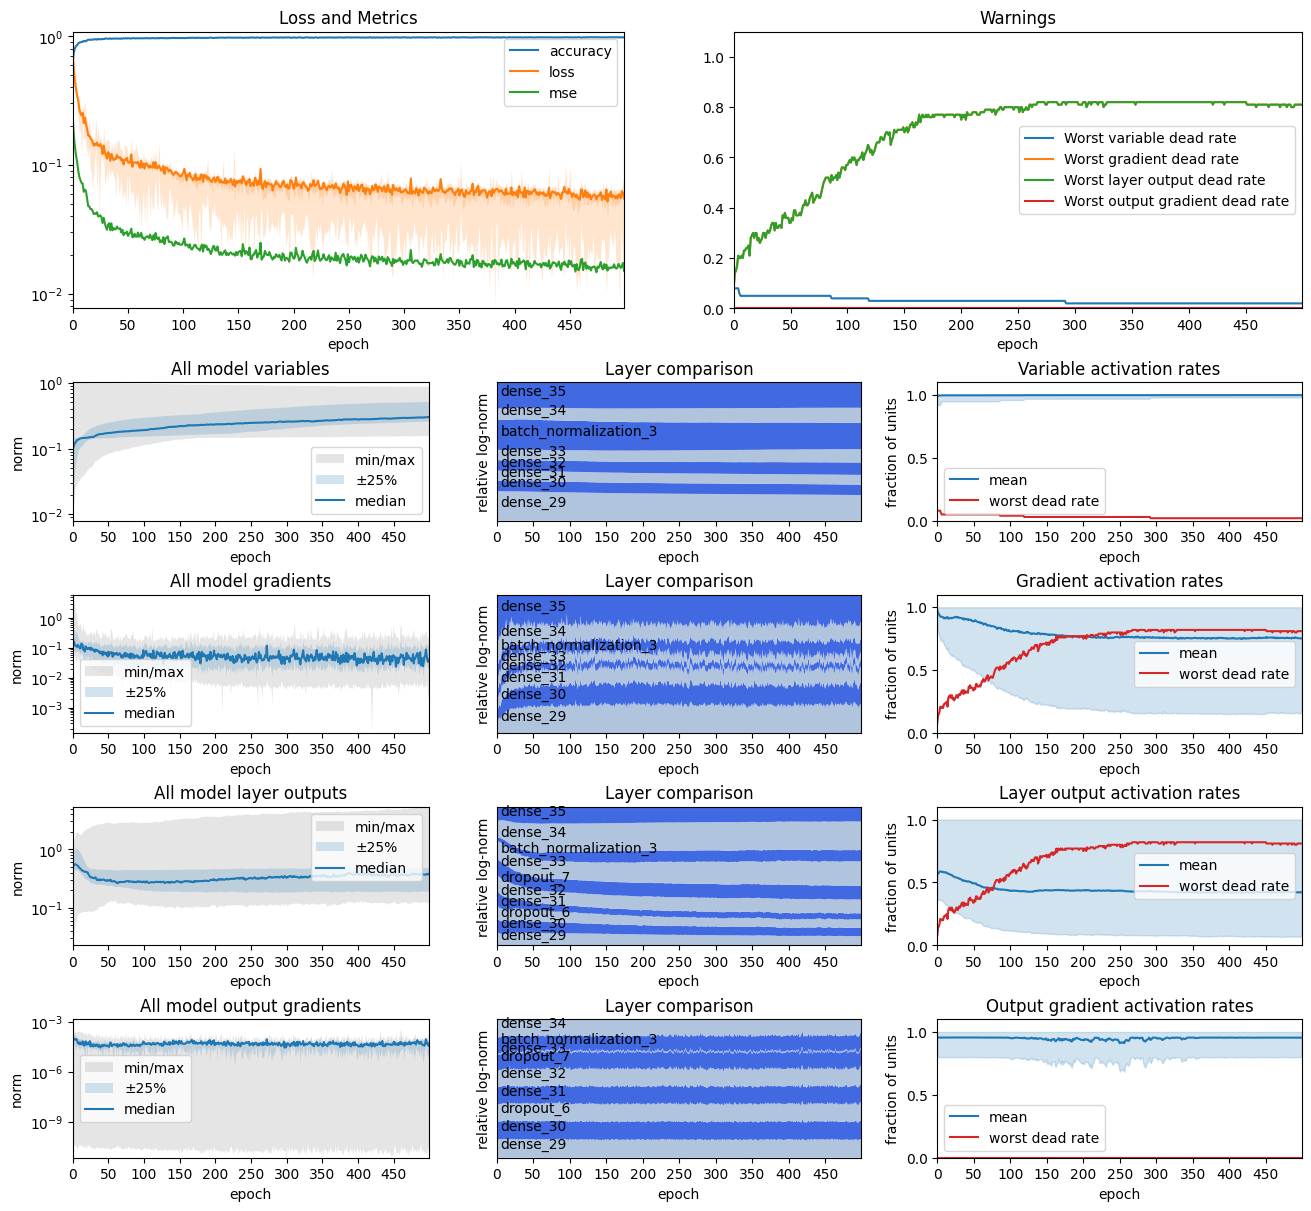

In [54]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

## Basic Plotting and Weights and Biases

To get an idea of the effects of initialization, we can create a dummy model with different initialization schemes and their the weights and biases before training.

In [46]:
def short_path(variable_path):
  """converts from 'sequential_3/dense1/kernel' to 'sequential_3/dense1/kernel'"""
  return "/".join(variable_path.split("/")[-2:])

def plot_variables(model):
  num_vars = len(model.trainable_variables)
  layer_indices = tinstr.layer_indices_by_trainable_variable(model)
  var_display_names = [f"layer {l_idx}:\n{short_path(v.path)}" for v, l_idx in zip(model.trainable_variables, layer_indices)]

  plot_cols = 4
  plot_rows = np.ceil(num_vars / plot_cols).astype(np.int32)
  plt.figure(figsize=(10, 2*plot_rows), layout='constrained')

  for v_idx, v in enumerate(model.trainable_variables):
    plt.subplot(plot_rows, plot_cols, v_idx+1)
    plt.title(var_display_names[v_idx])
    plt.hist(v.numpy().flatten(), bins=50)
    plt.xlabel("value")
    plt.ylabel("histogram count")
  plt.show()

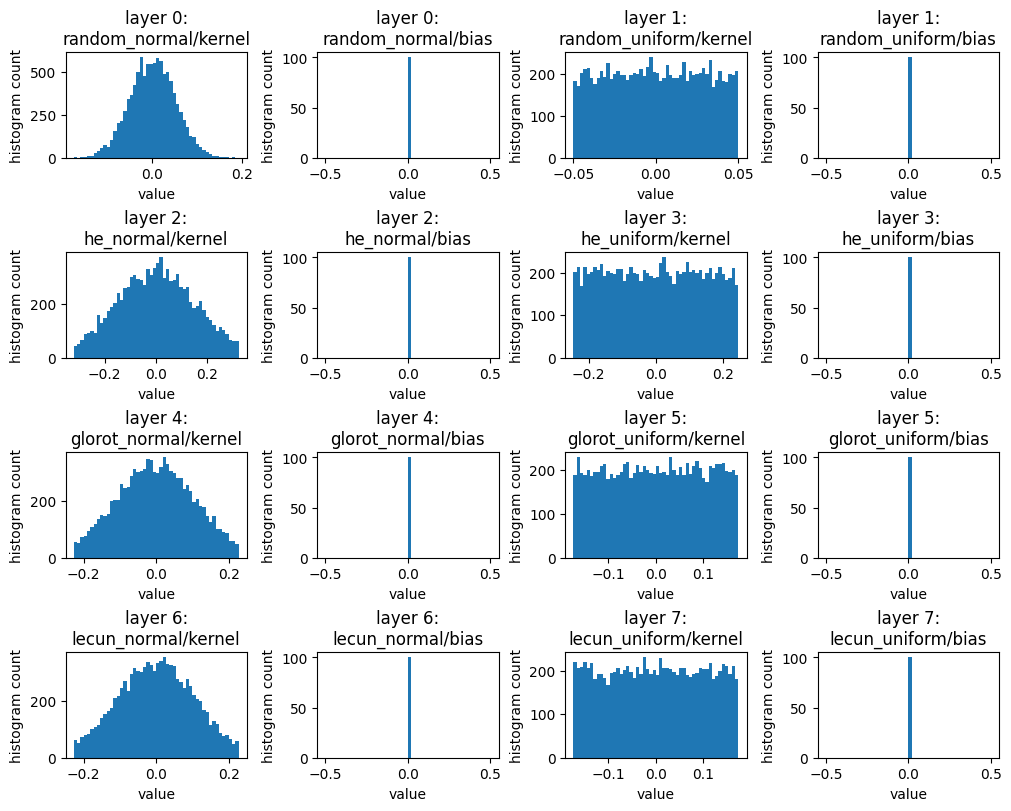

In [49]:
def mixed_initialization_model():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='random_normal', name='random_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='random_uniform', name='random_uniform'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_uniform', name='he_uniform'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='glorot_normal', name='glorot_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='glorot_uniform', name='glorot_uniform'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='lecun_normal', name='lecun_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='lecun_uniform', name='lecun_uniform')
  ])
  return model

plot_variables(mixed_initialization_model())

Compare that to an initialized version of the model we're actually using:

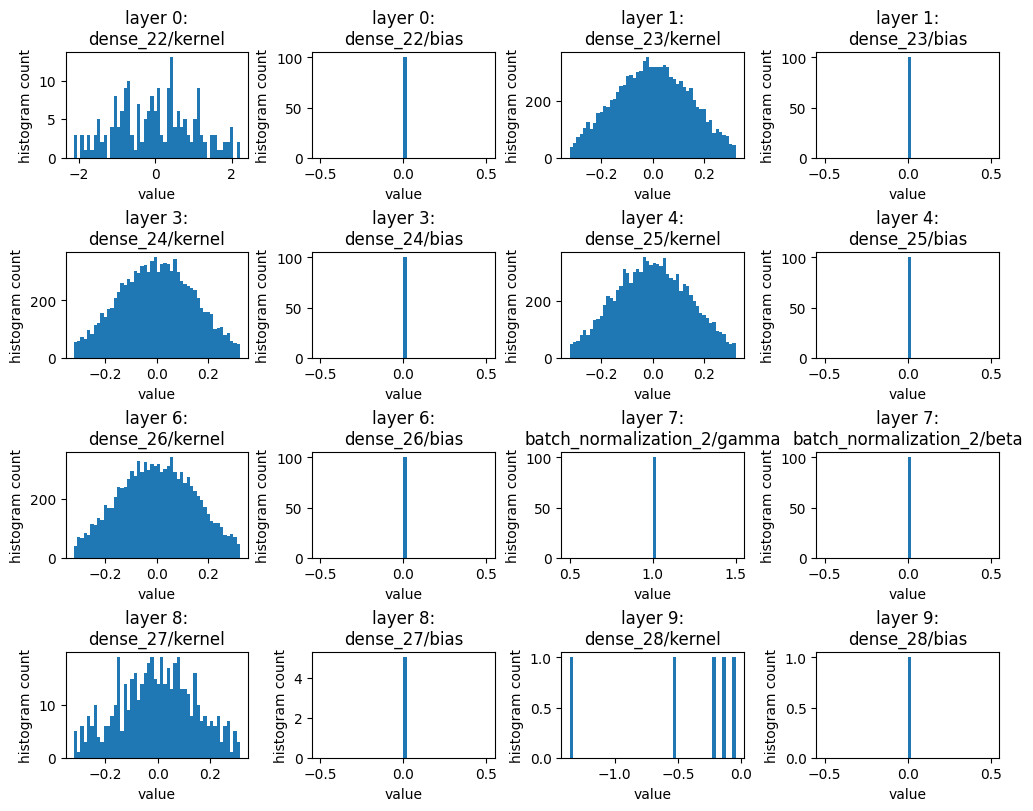

In [51]:
plot_variables(binary_classification_model())

And then for our trained model...

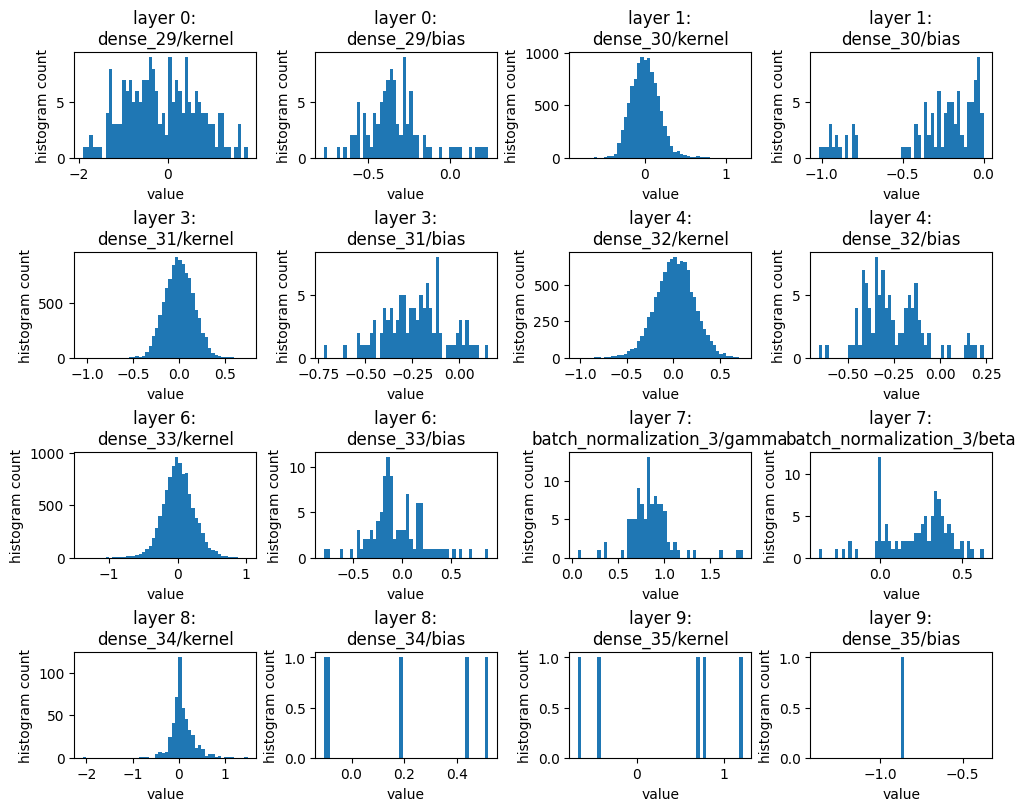

In [55]:
plot_variables(model)

## Plotting the weights and biases
There's several common ways of plotting weights:
* L2-norm aka euclidean norm (with/without size normalization)
* mean and stddev
* histograms

The following shows some of these options.


First, the L2-norm with size-normalization (ie: so that differently sized tensors still produce values on comparable scales), which is mathematically equivalent to calculating the RMS of the elements in each tensor:

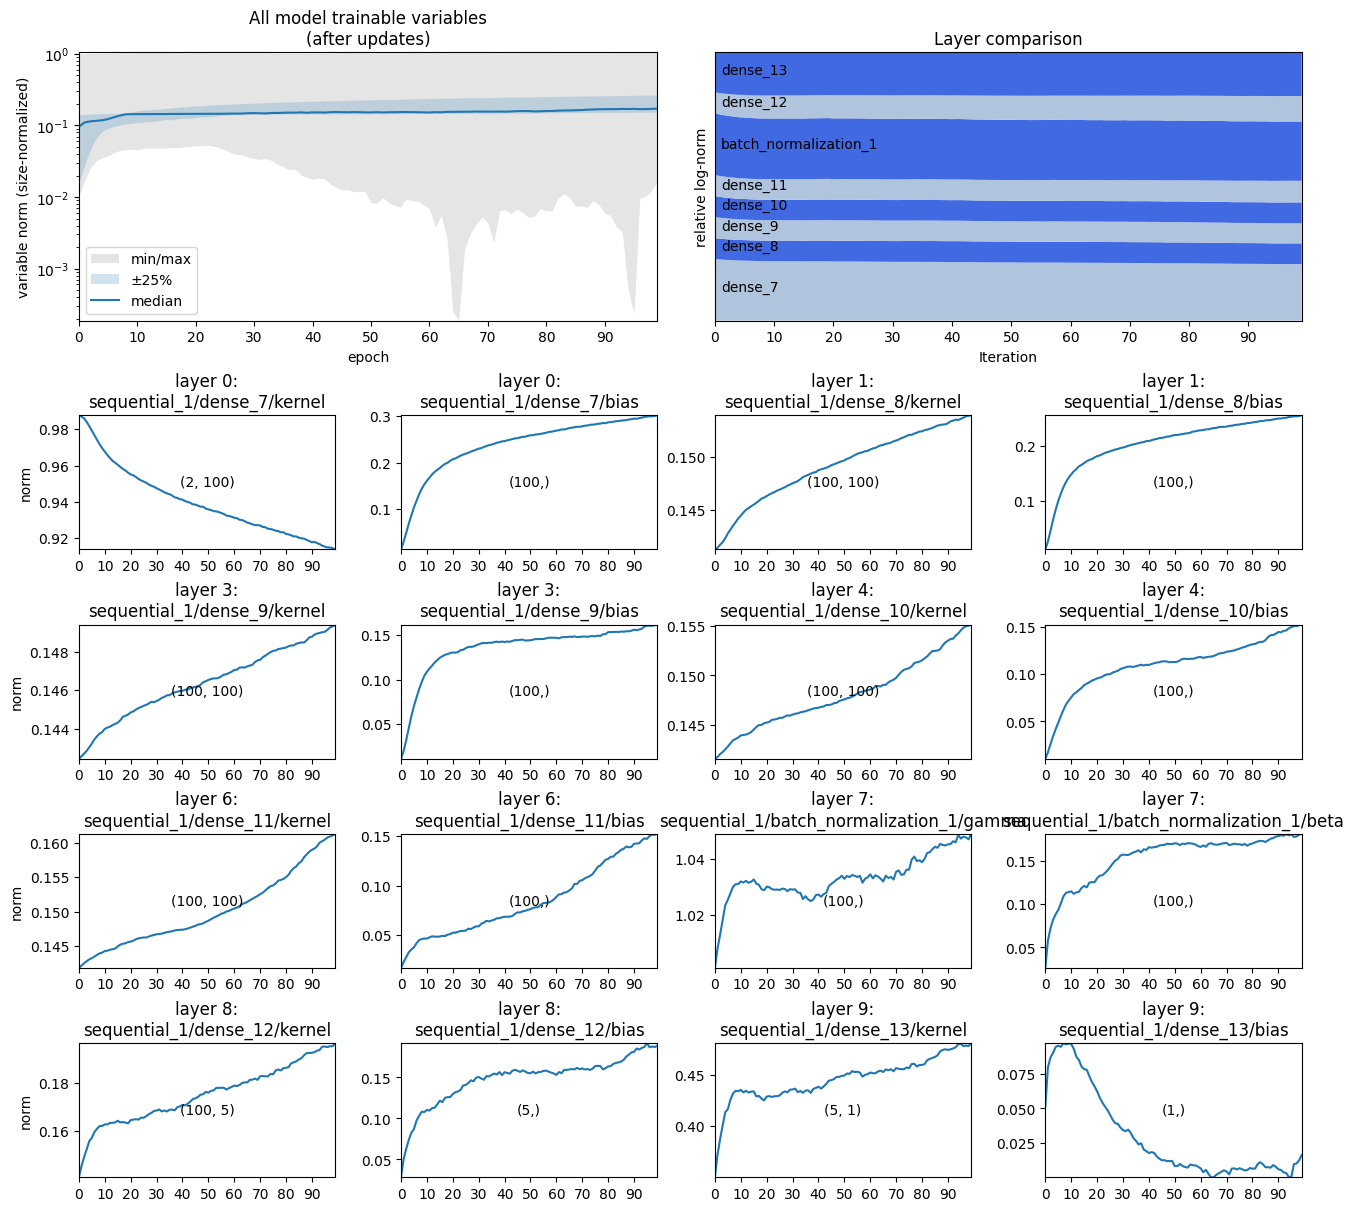

In [23]:
tinstr.plot_value_history(variables, show='norms', yscale='linear')

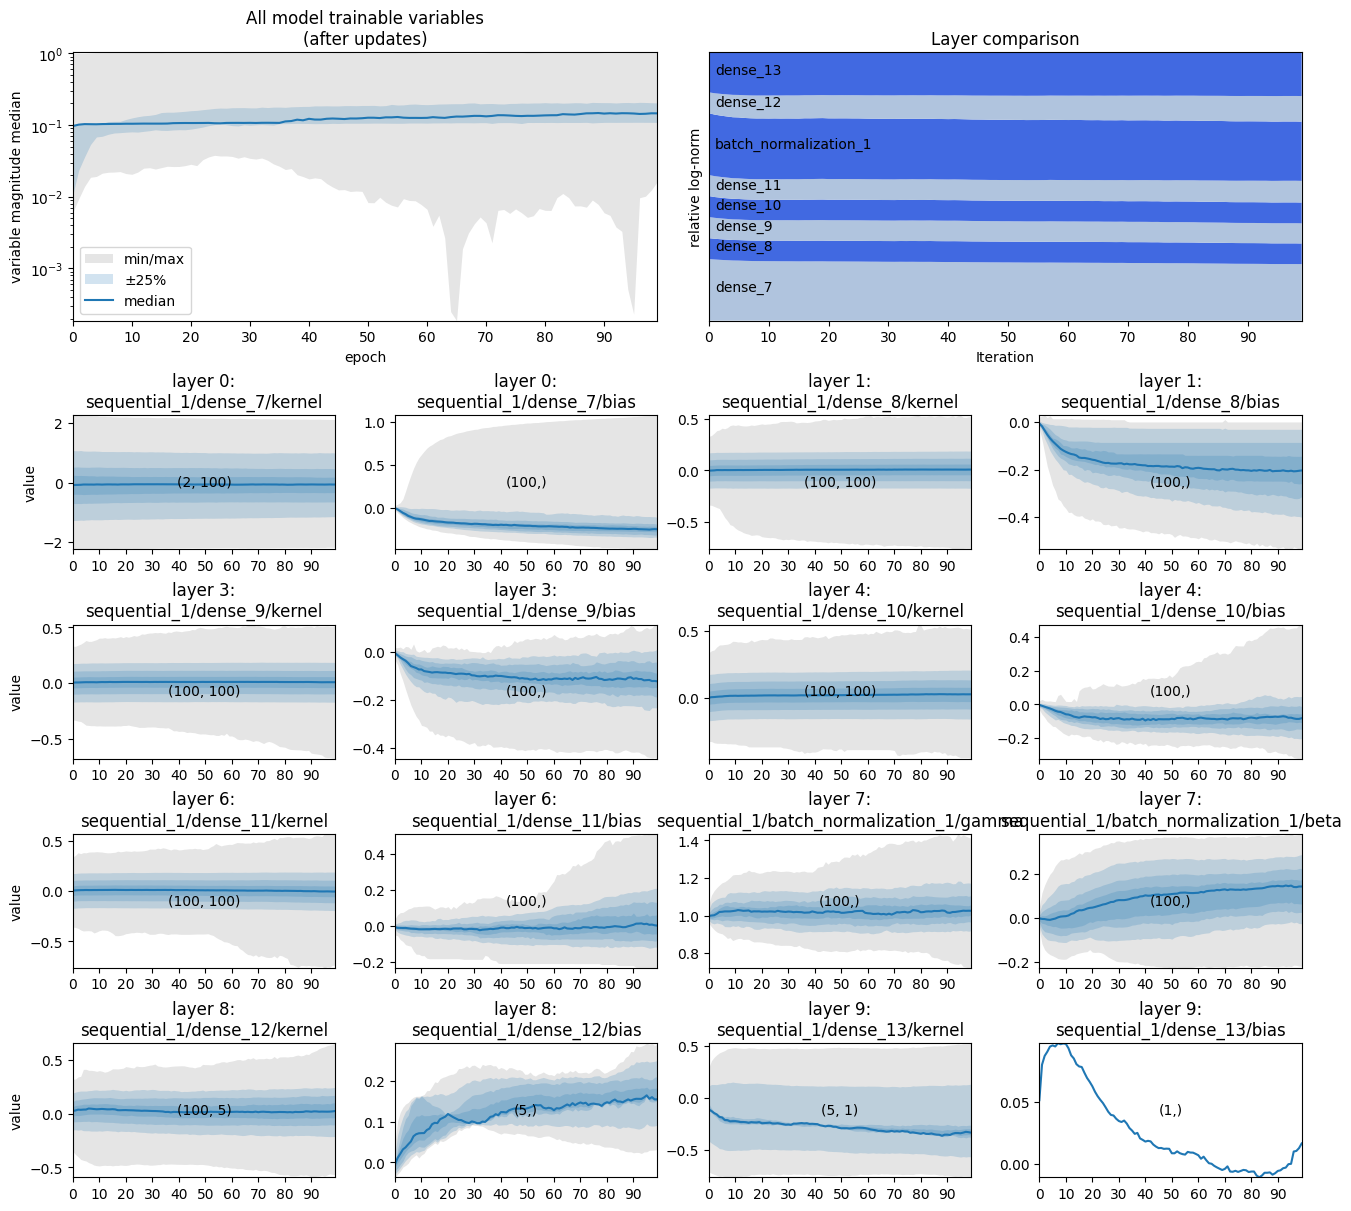

In [24]:
tinstr.plot_value_history(variables, show='values')

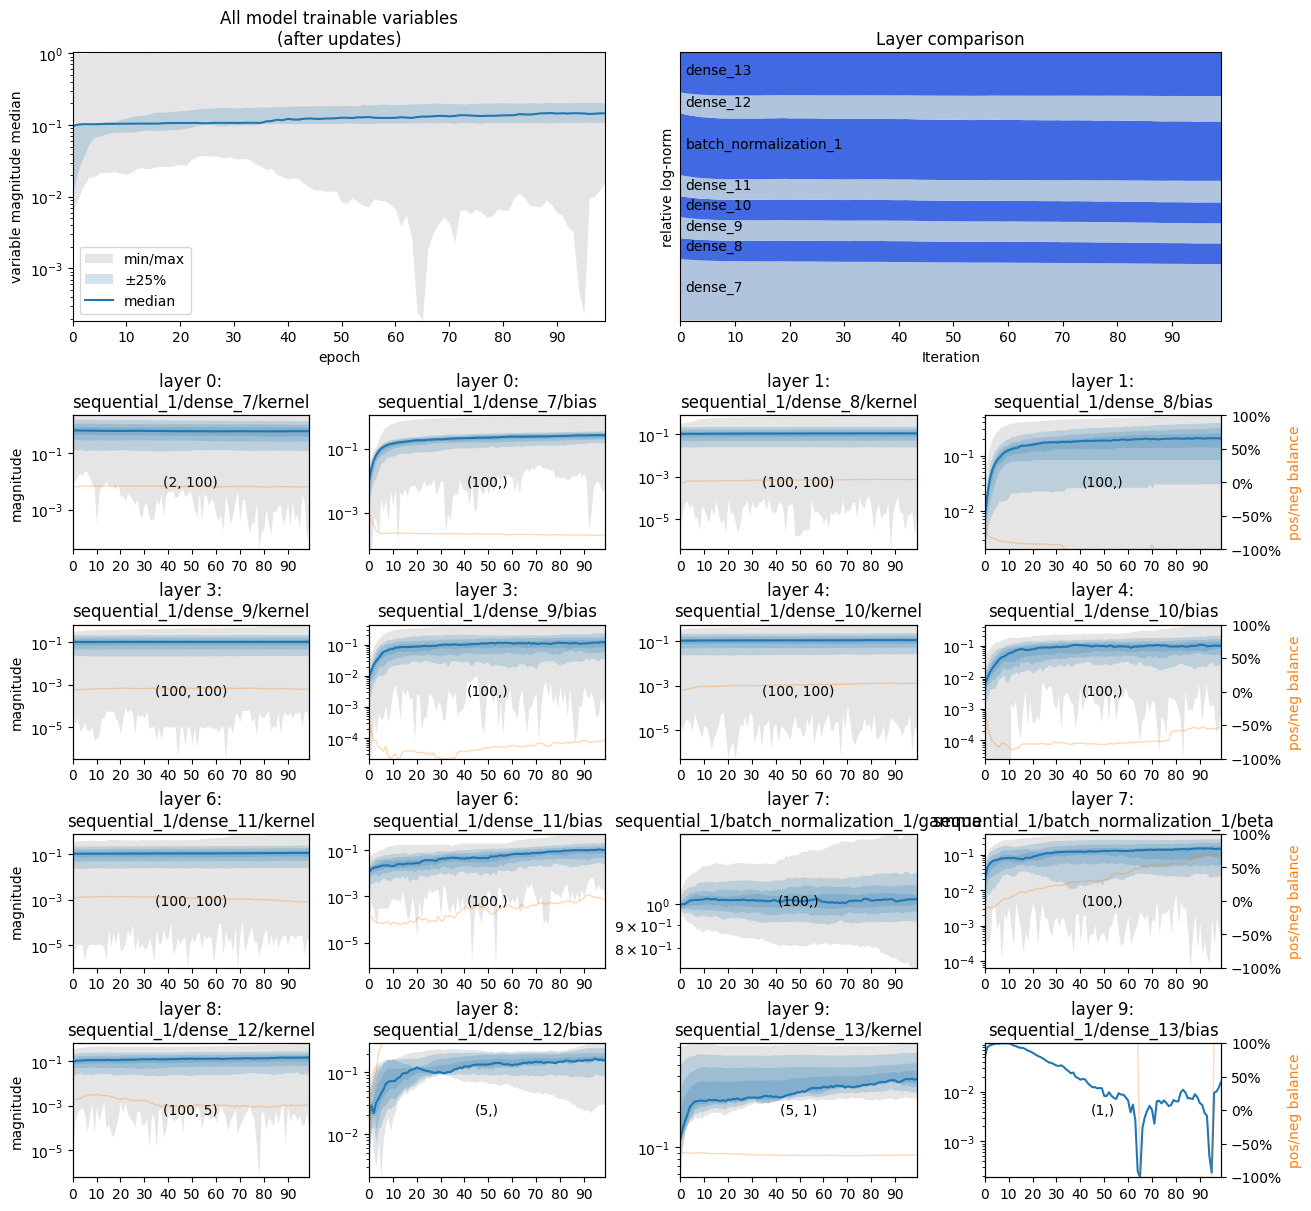

In [25]:
tinstr.plot_value_history(variables, show='magnitudes')

## MNIST classification

In [75]:
def mnist_dataset():
  (train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
  #class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
  # pre-process into the correct data range and just use the first 5000 images
  train_images = train_images[0:5000, :] / 255.0
  train_labels = train_labels[0:5000]
  print(f"train_images shape: {train_images.shape}")
  print(f"train_labels shape: {train_labels.shape}")

  return tf.data.Dataset.from_tensor_slices((train_images, train_labels)).batch(32)
mnist_dataset()

train_images shape: (5000, 28, 28)
train_labels shape: (5000,)


<_BatchDataset element_spec=(TensorSpec(shape=(None, 28, 28), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))>

In [73]:
def mnist_classification_model():
  inp = tf.keras.layers.Input((28, 28), name="input")
  x = tf.keras.layers.Reshape((28,28,1), name="reshape")(inp)
  x = tf.keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv1a")(x)
  x = tf.keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv1b")(x)
  x = tf.keras.layers.MaxPool2D(pool_size=2, padding='valid', name="pool1")(x)
  x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv2a")(x)
  x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv2b")(x)
  x = tf.keras.layers.MaxPool2D(pool_size=2, padding='valid', name="pool2")(x)
  x = tf.keras.layers.Flatten(name="flatten")(x)
  x = tf.keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal', name="dense1")(x)
  x = tf.keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal', name="dense2")(x)
  x = tf.keras.layers.Dense(units=10, kernel_initializer='glorot_normal', name="logits")(x)
  return tf.keras.Model(inputs=inp, outputs=x)

mnist_classification_model().summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1a (Conv2D)                      │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1b (Conv2D)                      │ (None, 24, 24, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 12, 12, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2a (Conv2D)                      │ (None, 10, 10, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2b (Conv2D)                      │ (None, 8, 8, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense2 (Dense)                       │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ logits (Dense)                       │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 99,834 (389.98 KB)

 Trainable params: 99,834 (389.98 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
def simple_mnist_model():
  model = tf.keras.Sequential([
      layers.Input(shape=(28, 28, 1)),
      layers.Flatten(),
      layers.Dense(256, activation="relu"),
      layers.Dropout(0.2),
      layers.Dense(128, activation="relu"),
      layers.Dropout(0.2),
      layers.Dense(10, activation="softmax")
  ])
  return model
simple_mnist_model().summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
def mnist_medium_model():
  model = tf.keras.Sequential([
      layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(128, 3, activation='relu'),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dropout(0.3),
      layers.Dense(10, activation='softmax')
  ])
  return model
mnist_medium_model().summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = mnist_classification_model()
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy', tf.keras.metrics.SparseCategoricalAccuracy()])
dataset = mnist_dataset()
history = tinstr.fit(model, dataset, epochs=10, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

train_images shape: (5000, 28, 28)
train_labels shape: (5000,)
Epoch     1 - 12.83s/epoch: accuracy: 0.6970  loss: 0.8525  sparse_categorical_accuracy: 0.6970  
Epoch     2 - 16.96s/epoch: accuracy: 0.8060  loss: 0.5277  sparse_categorical_accuracy: 0.8060  
Epoch     3 - 8.63s/epoch: accuracy: 0.8368  loss: 0.4415  sparse_categorical_accuracy: 0.8368  
Epoch     4 - 7.52s/epoch: accuracy: 0.8558  loss: 0.3808  sparse_categorical_accuracy: 0.8558  
Epoch     5 - 8.66s/epoch: accuracy: 0.8724  loss: 0.3338  sparse_categorical_accuracy: 0.8724  
Epoch     6 - 8.31s/epoch: accuracy: 0.8904  loss: 0.2966  sparse_categorical_accuracy: 0.8904  
Epoch     7 - 7.95s/epoch: accuracy: 0.9070  loss: 0.2613  sparse_categorical_accuracy: 0.9070  
Epoch     8 - 8.63s/epoch: accuracy: 0.9196  loss: 0.2357  sparse_categorical_accuracy: 0.9196  
Epoch     9 - 7.44s/epoch: accuracy: 0.9308  loss: 0.1993  sparse_categorical_accuracy: 0.9308  
Epoch    10 - 8.74s/epoch: accuracy: 0.9366  loss: 0.1763  spa

In [82]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = simple_mnist_model()
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy', tf.keras.metrics.SparseCategoricalAccuracy()])
dataset = mnist_dataset()
history = tinstr.fit(model, dataset, epochs=10, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

train_images shape: (5000, 28, 28)
train_labels shape: (5000,)
Epoch     1 - 5.93s/epoch: accuracy: 0.6696  loss: 0.9211  sparse_categorical_accuracy: 0.6696  


Epoch     2 - 5.69s/epoch: accuracy: 0.7872  loss: 0.5915  sparse_categorical_accuracy: 0.7872  
Epoch     3 - 2.38s/epoch: accuracy: 0.8176  loss: 0.5079  sparse_categorical_accuracy: 0.8176  
Epoch     4 - 3.38s/epoch: accuracy: 0.8328  loss: 0.4626  sparse_categorical_accuracy: 0.8328  
Epoch     5 - 2.40s/epoch: accuracy: 0.8504  loss: 0.4192  sparse_categorical_accuracy: 0.8504  
Epoch     6 - 2.42s/epoch: accuracy: 0.8560  loss: 0.3908  sparse_categorical_accuracy: 0.8560  
Epoch     7 - 2.37s/epoch: accuracy: 0.8648  loss: 0.3700  sparse_categorical_accuracy: 0.8648  
Epoch     8 - 2.56s/epoch: accuracy: 0.8698  loss: 0.3546  sparse_categorical_accuracy: 0.8698  
Epoch     9 - 3.47s/epoch: accuracy: 0.8774  loss: 0.3352  sparse_categorical_accuracy: 0.8774  
Epoch    10 - 2.39s/epoch: accuracy: 0.8780  loss: 0.3234  sparse_categorical_accuracy: 0.8780  
Total training time: 33.1 sec


In [85]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = mnist_medium_model()
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy', tf.keras.metrics.SparseCategoricalAccuracy()])
dataset = mnist_dataset()
history = tinstr.fit(model, dataset, epochs=10, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

train_images shape: (5000, 28, 28)
train_labels shape: (5000,)
Epoch     1 - 12.37s/epoch: accuracy: 0.6108  loss: 1.0728  sparse_categorical_accuracy: 0.6108  
Epoch     2 - 14.31s/epoch: accuracy: 0.7710  loss: 0.6300  sparse_categorical_accuracy: 0.7710  
Epoch     3 - 10.26s/epoch: accuracy: 0.7994  loss: 0.5393  sparse_categorical_accuracy: 0.7994  
Epoch     4 - 7.90s/epoch: accuracy: 0.8246  loss: 0.4817  sparse_categorical_accuracy: 0.8246  
Epoch     5 - 10.56s/epoch: accuracy: 0.8412  loss: 0.4277  sparse_categorical_accuracy: 0.8412  
Epoch     6 - 9.04s/epoch: accuracy: 0.8582  loss: 0.3868  sparse_categorical_accuracy: 0.8582  
Epoch     7 - 8.27s/epoch: accuracy: 0.8748  loss: 0.3507  sparse_categorical_accuracy: 0.8748  
Epoch     8 - 9.91s/epoch: accuracy: 0.8798  loss: 0.3302  sparse_categorical_accuracy: 0.8798  
Epoch     9 - 9.06s/epoch: accuracy: 0.8918  loss: 0.3106  sparse_categorical_accuracy: 0.8918  
Epoch    10 - 10.68s/epoch: accuracy: 0.8980  loss: 0.2857  